In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.express as px

In [2]:
filename='outline_prediction_comparison.xlsx'
df= pd.read_excel(filename)
df

,Unnamed: 0,area,major_minor_ratio,mean_intensity_a,mean_intensity_v,mean_intensity_f,fraction_bdy,fraction_broken,fraction_3,leak_on_bdy,...,fraction_bdy_p,fraction_broken_p,fraction_3_p,leak_on_bdy_p,leak_on_broke_p,centroid_x_p,centroid_y_p,celltype_p,image_idx_p,cell_idx_p
0,0,77362,5.35,75.18,107.62,0,0.83,0.08,0,0,...,0.23,0.00,0,0,0,484.47,331.71,UF,1,10
1,1,59693,7.19,75.61,84.49,0,0.70,0.13,0,0,...,0.27,0.00,0,0,0,581.94,609.66,UF,1,12
2,2,37061,6.31,68.01,94.73,0,0.72,0.06,0,0,...,0.40,0.00,0,0,0,618.60,236.91,UF,1,15
3,3,34613,6.07,86.66,114.91,0,0.87,0.00,0,0,...,0.31,0.00,0,0,0,770.79,519.24,UF,1,16
4,4,31973,7.73,57.42,90.43,0,0.88,0.00,0,0,...,0.38,0.00,0,0,0,898.41,535.75,UF,1,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,299,53477,4.16,58.47,52.31,0,0.88,0.00,0,0,...,0.22,0.00,0,0,0,225.58,403.31,UF,237,6
300,300,37003,5.24,71.82,111.29,0,0.75,0.12,0,0,...,0.34,0.00,0,0,0,669.28,786.78,UF,237,14
301,301,53918,3.88,111.60,141.25,0,0.75,0.03,0,0,...,0.00,0.00,0,0,0,0.00,237.00,0,0,0
302,302,39923,4.21,56.86,91.12,0,0.77,0.09,0,0,...,0.25,0.01,0,0,0,824.75,713.39,UF,237,16


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           304 non-null    int64  
 1   area                 304 non-null    int64  
 2   major_minor_ratio    304 non-null    float64
 3   mean_intensity_a     304 non-null    float64
 4   mean_intensity_v     304 non-null    float64
 5   mean_intensity_f     304 non-null    int64  
 6   fraction_bdy         304 non-null    float64
 7   fraction_broken      304 non-null    float64
 8   fraction_3           304 non-null    int64  
 9   leak_on_bdy          304 non-null    int64  
 10  leak_on_broke        304 non-null    int64  
 11  centroid_x           304 non-null    float64
 12  centroid_y           304 non-null    float64
 13  celltype             304 non-null    object 
 14  image_idx            304 non-null    int64  
 15  cell_idx             304 non-null    int

In [5]:
from sklearn.preprocessing import StandardScaler

# Extract the selected feature pair for actual values
selected_feature_x, selected_feature_y = "fraction_3", "fraction_1_p"

# Determine corresponding predicted features
selected_feature_x_p = selected_feature_x + "_p"
selected_feature_y_p = selected_feature_y + "_p"

def plot_actual_vs_predicted(df, feature_x, feature_y):
    """
    Generates side-by-side scatter plots for actual and predicted values
    to visualize clustering of UF vs DF cells.

    Parameters:
    - df (DataFrame): Dataset containing cell information.
    - feature_x (str): Actual feature X.
    - feature_y (str): Actual feature Y.
    """
    # Determine predicted feature names
    feature_x_p = feature_x + "_p"
    feature_y_p = feature_y + "_p"

    # Filter relevant columns and remove unexpected values
    df_filtered = df[['celltype_p', feature_x, feature_y, feature_x_p, feature_y_p]].copy()
    df_filtered.rename(columns={'celltype_p': 'Cell Type'}, inplace=True)

    # Keep only UF and DF categories
    df_filtered = df_filtered[df_filtered['Cell Type'].isin(['UF', 'DF'])]

    # Standardize the features
    scaler = StandardScaler()
    df_filtered[[feature_x, feature_y, feature_x_p, feature_y_p]] = scaler.fit_transform(
        df_filtered[[feature_x, feature_y, feature_x_p, feature_y_p]]
    )

    # Define color palette dynamically
    unique_types = df_filtered['Cell Type'].unique()
    palette = {ctype: color for ctype, color in zip(unique_types, ['blue', 'red'])}

    # Create side-by-side scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Scatter plot for actual values
    sns.scatterplot(
        data=df_filtered, x=feature_x, y=feature_y, hue='Cell Type',
        palette=palette, alpha=0.7, edgecolor='black', ax=axes[0]
    )
    axes[0].set_title(f'Actual: {feature_x} vs. {feature_y}')
    axes[0].set_xlabel(f'Standardized {feature_x}')
    axes[0].set_ylabel(f'Standardized {feature_y}')

    # Scatter plot for predicted values
    sns.scatterplot(
        data=df_filtered, x=feature_x_p, y=feature_y_p, hue='Cell Type',
        palette=palette, alpha=0.7, edgecolor='black', ax=axes[1]
    )
    axes[1].set_title(f'Predicted: {feature_x_p} vs. {feature_y_p}')
    axes[1].set_xlabel(f'Standardized {feature_x_p}')
    axes[1].set_ylabel(f'Standardized {feature_y_p}')

    # Improve layout and display
    plt.tight_layout()
    plt.show()

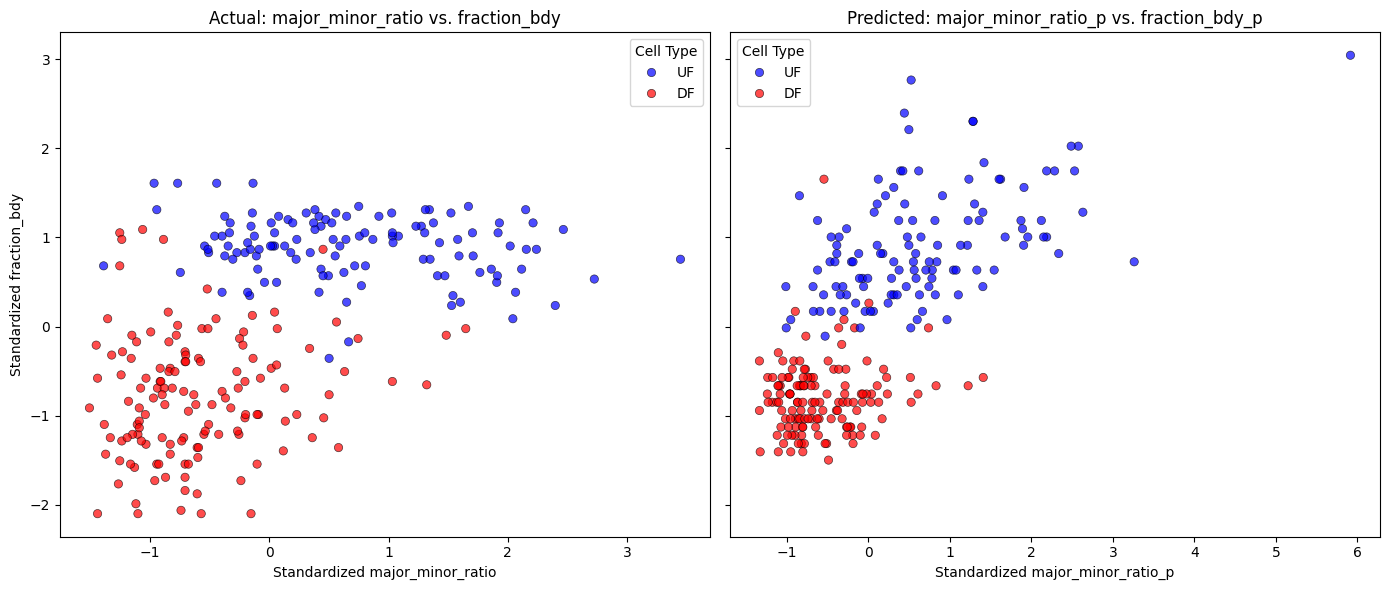

In [7]:
plot_actual_vs_predicted(df, feature_x="major_minor_ratio", feature_y="fraction_bdy")

In [8]:
# Import necessary libraries

def find_best_feature_pairs_separately(df, features, n_top=5):
    """
    Identifies the best feature pairs for clustering UF vs DF cells based on silhouette score,
    separately for actual and predicted values.

    Parameters:
    - df (DataFrame): Dataset containing feature values and cell types.
    - features (list): List of actual feature column names (predicted columns are assumed as feature + "_p").
    - n_top (int): Number of top-ranked feature pairs to return.

    Returns:
    - best_actual_pairs (list): Top actual feature pairs with highest silhouette scores.
    - best_predicted_pairs (list): Top predicted feature pairs with highest silhouette scores.
    """
    # Filter relevant data and remove invalid cell types
    df_filtered = df[df['celltype_p'].isin(['UF', 'DF'])].copy()

    # Encode cell type as numeric (UF=0, DF=1)
    df_filtered['Cell Type'] = df_filtered['celltype_p'].map({'UF': 0, 'DF': 1})

    best_actual_pairs = []
    best_predicted_pairs = []

    # Iterate over all possible feature pairs for actual values
    for feat_x, feat_y in combinations(features, 2):
        # Standardize the selected features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_filtered[[feat_x, feat_y]])

        # Compute silhouette score
        if len(set(df_filtered['Cell Type'])) > 1:  # Ensure at least two classes exist
            score = silhouette_score(scaled_features, df_filtered['Cell Type'])
            best_actual_pairs.append((feat_x, feat_y, score))

    # Iterate over all possible feature pairs for predicted values
    predicted_features = [feat + "_p" for feat in features if feat + "_p" in df.columns]
    for feat_x, feat_y in combinations(predicted_features, 2):
        # Standardize the selected features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_filtered[[feat_x, feat_y]])

        # Compute silhouette score
        if len(set(df_filtered['Cell Type'])) > 1:  # Ensure at least two classes exist
            score = silhouette_score(scaled_features, df_filtered['Cell Type'])
            best_predicted_pairs.append((feat_x, feat_y, score))

    # Sort pairs by silhouette score (descending order)
    best_actual_pairs = sorted(best_actual_pairs, key=lambda x: x[2], reverse=True)[:n_top]
    best_predicted_pairs = sorted(best_predicted_pairs, key=lambda x: x[2], reverse=True)[:n_top]

    return best_actual_pairs, best_predicted_pairs

# Select numerical features for evaluation (excluding non-feature columns)
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
exclude_cols = ['Unnamed: 0', 'image_idx_p', 'cell_idx_p', 'celltype_p', 'Cell Type']
features_to_check = [feat for feat in numeric_features if feat not in exclude_cols and not feat.endswith("_p")]

# Find the best feature pairs separately for actual and predicted values
best_actual_pairs, best_predicted_pairs = find_best_feature_pairs_separately(df, features_to_check, n_top=5)

# Display the best feature pairs for actual and predicted separately
best_actual_df = pd.DataFrame(best_actual_pairs, columns=['Feature X', 'Feature Y', 'Silhouette Score'])
best_predicted_df = pd.DataFrame(best_predicted_pairs, columns=['Feature X', 'Feature Y', 'Silhouette Score'])


In [9]:
best_actual_df

,Feature X,Feature Y,Silhouette Score
0,mean_intensity_f,fraction_broken,0.631423
1,fraction_broken,fraction_3,0.631423
2,fraction_broken,leak_on_bdy,0.631423
3,fraction_broken,leak_on_broke,0.631423
4,fraction_bdy,fraction_broken,0.606911


In [10]:
best_predicted_df

,Feature X,Feature Y,Silhouette Score
0,mean_intensity_f_p,fraction_broken_p,0.744826
1,fraction_broken_p,fraction_3_p,0.744826
2,fraction_broken_p,leak_on_bdy_p,0.744826
3,fraction_broken_p,leak_on_broke_p,0.744826
4,fraction_bdy_p,fraction_broken_p,0.672669


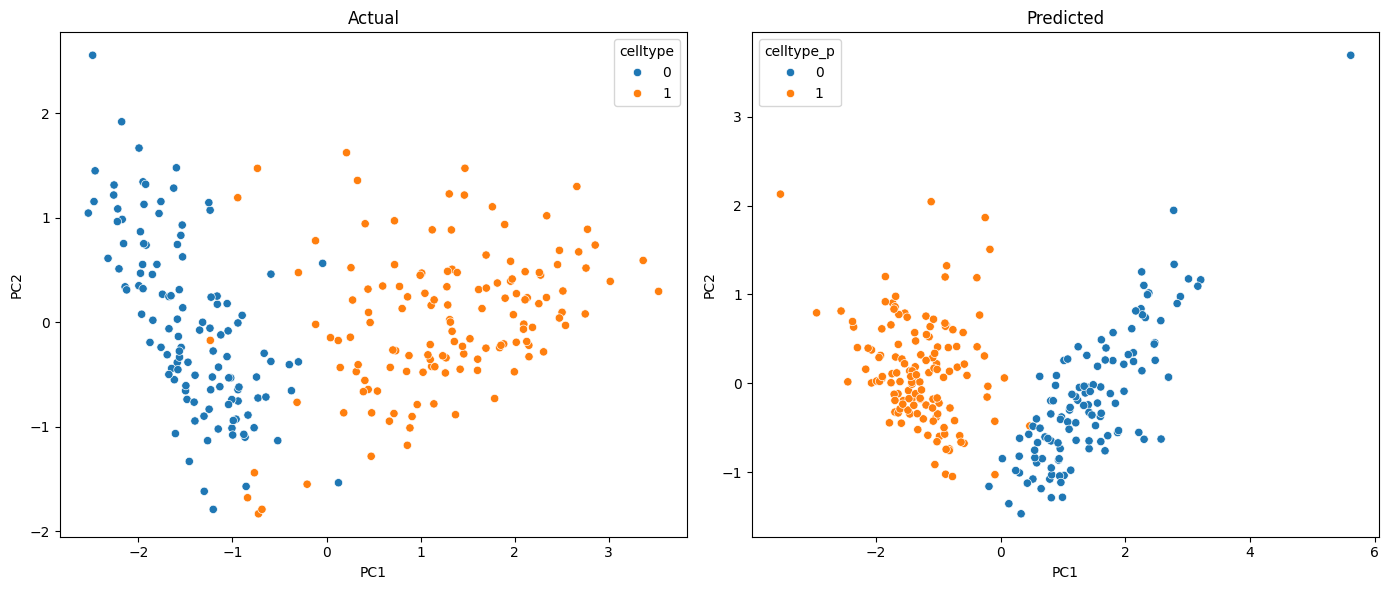

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.express as px

# Create the actual and predicted column lists
actual_cols = ['major_minor_ratio', 'fraction_bdy', 'fraction_broken', 'fraction_3', 'celltype']
predicted_cols = [col + '_p' for col in actual_cols] 

# Create separate DataFrames for actual and predicted features
df_actual = df[actual_cols].copy()
df_predicted = df[predicted_cols].copy()

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Filter rows where 'celltype_p' is 'UF' or 'DF'
df_filtered_actual = df[df['celltype_p'].isin(['UF', 'DF'])].copy()
df_filtered_predicted = df[df['celltype_p'].isin(['UF', 'DF'])].copy()

# Recreate 'Cell Type' column
df_filtered_actual['celltype'] = df_filtered_actual['celltype'].map({'UF': 0, 'DF': 1})
df_filtered_predicted['celltype_p'] = df_filtered_predicted['celltype_p'].map({'UF': 0, 'DF': 1})

# Define features (excluding 'Cell Type') for actual and predicted
actual_features = ['major_minor_ratio', 'fraction_bdy', 'fraction_broken', 'fraction_3']
predicted_features = [col + '_p' for col in actual_features]

# Standardize the features
scaler = StandardScaler()
actual_scaled = scaler.fit_transform(df_filtered_actual[actual_features])
predicted_scaled = scaler.fit_transform(df_filtered_predicted[predicted_features])

# Run PCA (2 components)
pca = PCA(n_components=2)
actual_pca = pca.fit_transform(actual_scaled)
predicted_pca = pca.fit_transform(predicted_scaled)

# Convert to DataFrames for plotting
actual_pca_df = pd.DataFrame(actual_pca, columns=['PC1', 'PC2'])
actual_pca_df['celltype'] = df_filtered_actual['celltype'].values

predicted_pca_df = pd.DataFrame(predicted_pca, columns=['PC1', 'PC2'])
predicted_pca_df['celltype_p'] = df_filtered_predicted['celltype_p'].values


# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.scatterplot(data=actual_pca_df, x='PC1', y='PC2', hue='celltype', ax=axes[0])
axes[0].set_title('Actual')
sns.scatterplot(data=predicted_pca_df, x='PC1', y='PC2', hue='celltype_p',  ax=axes[1])
axes[1].set_title('Predicted')

plt.tight_layout()
plt.show()



In [14]:
# Retrieve PCA components and explained variance for actual and predicted features
actual_pca_model = PCA(n_components=2)
actual_pca_model.fit(actual_scaled)

predicted_pca_model = PCA(n_components=2)
predicted_pca_model.fit(predicted_scaled)

# Create summary DataFrames
actual_pca_summary = pd.DataFrame({
    'Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': actual_pca_model.explained_variance_ratio_,
    'Actual Component Weights': list(actual_pca_model.components_)
})

predicted_pca_summary = pd.DataFrame({
    'Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': predicted_pca_model.explained_variance_ratio_,
    'Predicted Component Weights': list(predicted_pca_model.components_)
})

actual_pca_summary

,Component,Explained Variance Ratio,Actual Component Weights
0,PC1,0.802489,"[-0.4846325658493302, -0.6141526057453937, 0.6..."
1,PC2,0.189810,"[0.8735387024755492, -0.37676925919640714, 0.3..."


In [15]:
predicted_pca_summary

,Component,Explained Variance Ratio,Predicted Component Weights
0,PC1,0.793643,"[0.5328114354986814, 0.616111657849702, -0.580..."
1,PC2,0.160277,"[0.8105654460466362, -0.17464440847127055, 0.5..."


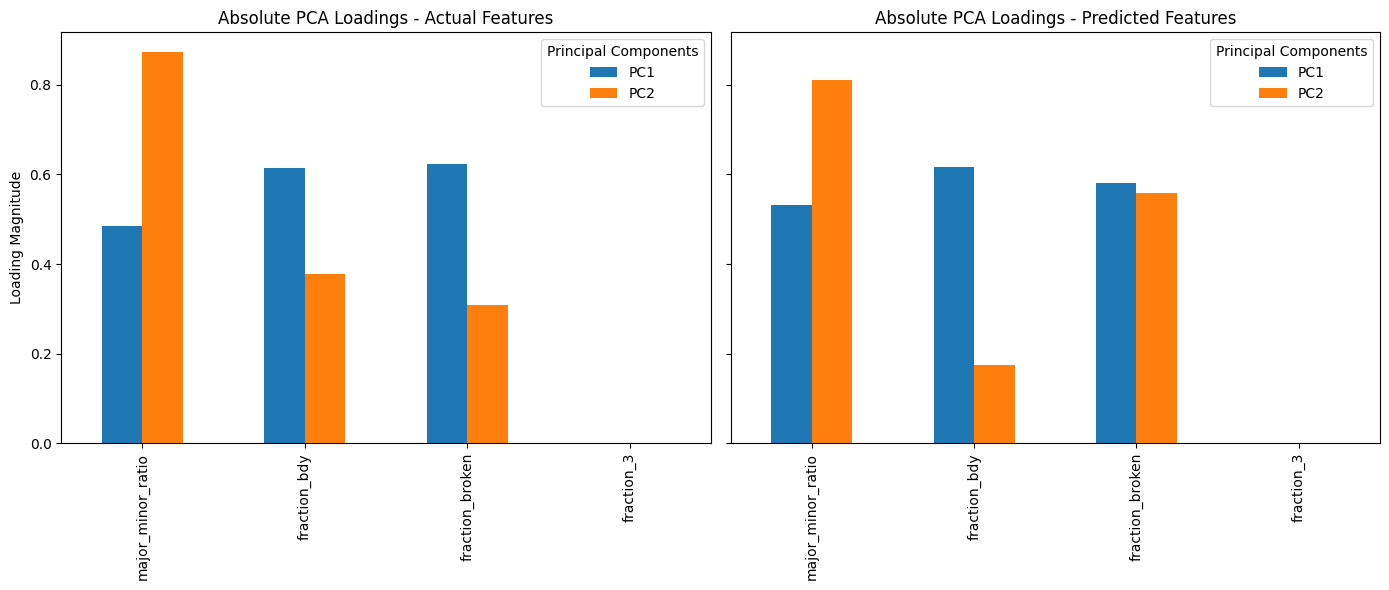

In [16]:
# Extract and prepare absolute PCA loadings for visualization
actual_loadings = pd.DataFrame(
    abs(actual_pca_model.components_),
    columns=actual_features,
    index=['PC1', 'PC2']
)

predicted_loadings = pd.DataFrame(
    abs(predicted_pca_model.components_),
    columns=actual_features,  # Predicted used same base features
    index=['PC1', 'PC2']
)

# Plot side-by-side barplots for PCA loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

actual_loadings.T.plot(kind='bar', ax=axes[0])
axes[0].set_title("Absolute PCA Loadings - Actual Features")
axes[0].set_ylabel("Loading Magnitude")
axes[0].legend(title='Principal Components')

predicted_loadings.T.plot(kind='bar', ax=axes[1])
axes[1].set_title("Absolute PCA Loadings - Predicted Features")
axes[1].legend(title='Principal Components')

plt.tight_layout()
plt.show()

In [17]:
# Select numerical features for PCA (excluding non-feature columns)
numeric_features = df.select_dtypes(include=['number']).columns.tolist()

exclude_cols = ['Unnamed: 0', 'image_idx_p', 'cell_idx_p', 'celltype_p']
selected_features = [feat for feat in numeric_features if feat not in exclude_cols]
# Ensure dataset contains valid cell types (UF = healthy, DF = diseased)
df_filtered = df[df['celltype_p'].isin(['UF', 'DF'])].copy()
# Encode cell type as numeric (UF=0, DF=1)
df_filtered['Cell Type'] = df_filtered['celltype_p'].map({'UF': 0, 'DF': 1})

# Perform PCA for actual features
scaler = StandardScaler()
standardized_features = scaler.fit_transform(df_filtered[selected_features])
pca_actual = PCA(n_components=3)
pca_actual_result = pca_actual.fit_transform(standardized_features)

# Perform PCA for predicted features
predicted_features = [feat + "_p" for feat in selected_features if feat + "_p" in df_filtered.columns]
standardized_predicted_features = scaler.fit_transform(df_filtered[predicted_features])
pca_predicted = PCA(n_components=3)
pca_predicted_result = pca_predicted.fit_transform(standardized_predicted_features)

# Create DataFrames for actual and predicted PCA results
pca_df_actual = pd.DataFrame(data=pca_actual_result, columns=['PC1', 'PC2', 'PC3'])
pca_df_actual['Cell Type'] = df_filtered['celltype_p'].values
pca_df_actual['Type'] = 'Actual'

pca_df_predicted = pd.DataFrame(data=pca_predicted_result, columns=['PC1', 'PC2', 'PC3'])
pca_df_predicted['Cell Type'] = df_filtered['celltype_p'].values
pca_df_predicted['Type'] = 'Predicted'

# Concatenate actual and predicted results
pca_combined_df = pd.concat([pca_df_actual, pca_df_predicted], ignore_index=True)

explained_variance_actual = pd.DataFrame({
    "Principal Component": ['PC1', 'PC2', 'PC3'],
    "Explained Variance Ratio": pca_actual.explained_variance_ratio_
})

explained_variance_predicted = pd.DataFrame({
    "Principal Component": ['PC1', 'PC2', 'PC3'],
    "Explained Variance Ratio": pca_predicted.explained_variance_ratio_
})

# Extract PCA component loadings (feature contributions to PCs)
pca_components_actual = pd.DataFrame(
    pca_actual.components_.T, index=selected_features, columns=['PC1', 'PC2', 'PC3']
)

pca_components_predicted = pd.DataFrame(
    pca_predicted.components_.T, index=predicted_features, columns=['PC1', 'PC2', 'PC3']
)



In [18]:


print(explained_variance_actual)



print(explained_variance_predicted)



print(pca_components_actual)



  Principal Component  Explained Variance Ratio
0                 PC1                  0.272256
1                 PC2                  0.156953
2                 PC3                  0.146508
  Principal Component  Explained Variance Ratio
0                 PC1                  0.286701
1                 PC2                  0.167983
2                 PC3                  0.150704
                              PC1       PC2           PC3
area                -1.724563e-01  0.247103 -7.279159e-02
major_minor_ratio    3.583161e-01  0.010105 -2.551703e-02
mean_intensity_a     4.861221e-02  0.352620  2.938722e-01
mean_intensity_v     1.414639e-01  0.351219  3.194181e-02
mean_intensity_f    -6.938894e-18  0.000000 -2.081668e-17
fraction_bdy         3.879556e-01  0.028126 -2.764853e-02
fraction_broken     -4.060233e-01 -0.017289  6.326629e-03
fraction_3          -0.000000e+00  0.000000  1.110223e-16
leak_on_bdy         -0.000000e+00  0.000000  1.110223e-16
leak_on_broke       -1.694066e-21  0

<Figure size 1000x600 with 0 Axes>

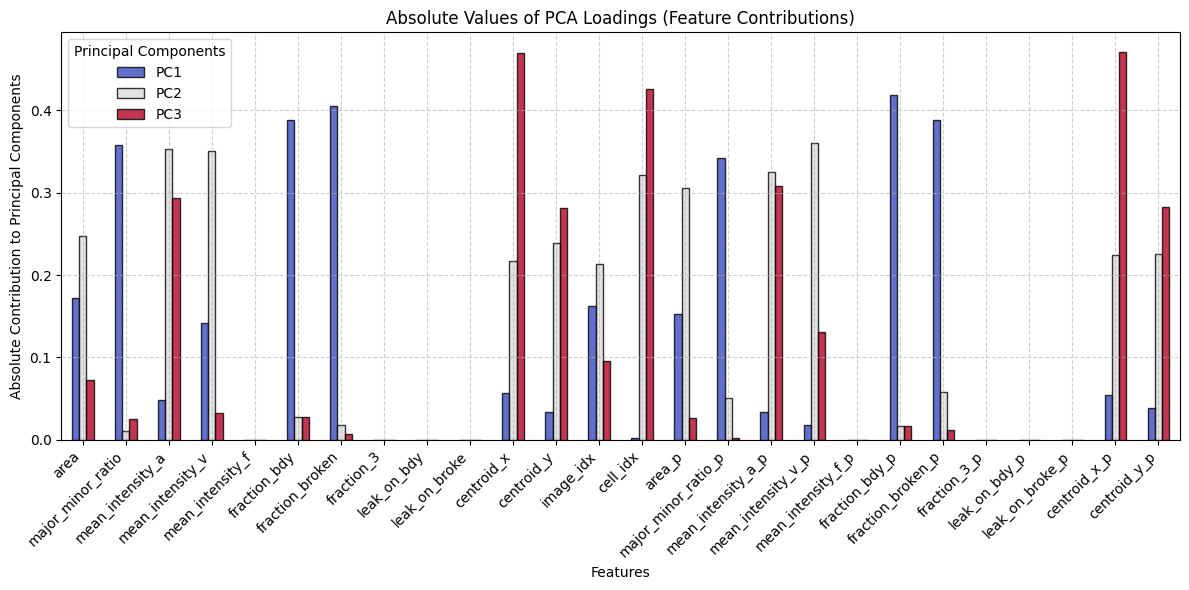

In [19]:
# Compute absolute values of PCA loadings for better visualization
pca_abs_loadings = pca_components_actual.abs()

# Plot the absolute PCA loadings
plt.figure(figsize=(10, 6))
pca_abs_loadings.plot(kind='bar', figsize=(12, 6), colormap="coolwarm", alpha=0.8, edgecolor="black")

plt.title("Absolute Values of PCA Loadings (Feature Contributions)")
plt.xlabel("Features")
plt.ylabel("Absolute Contribution to Principal Components")
plt.legend(title="Principal Components")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()

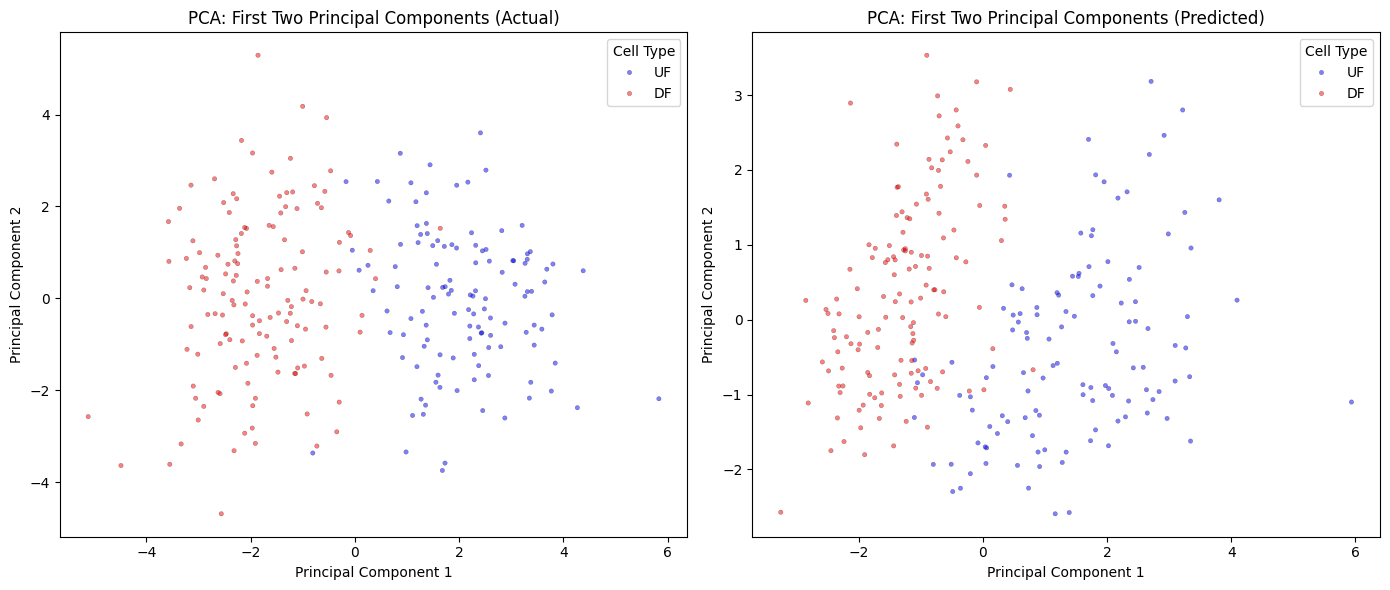

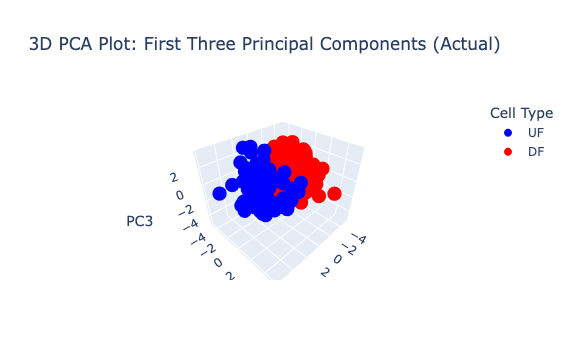

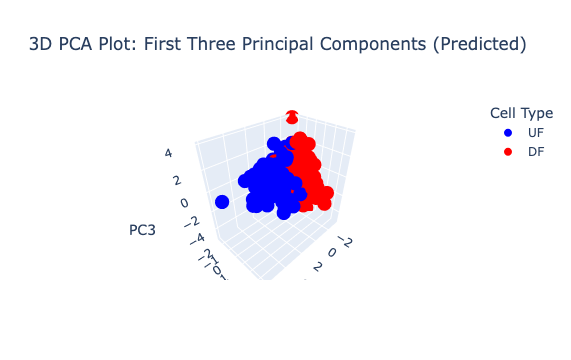

In [20]:
# Plot side-by-side PCA Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for actual values
sns.scatterplot(
    data=pca_df_actual, x='PC1', y='PC2', hue='Cell Type', alpha=0.5,
    palette={'UF': 'blue', 'DF': 'red'}, edgecolor='black', s=10, ax=axes[0]
)
axes[0].set_title('PCA: First Two Principal Components (Actual)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Scatter plot for predicted values
sns.scatterplot(
    data=pca_df_predicted, x='PC1', y='PC2', hue='Cell Type', alpha=0.5,
    palette={'UF': 'blue', 'DF': 'red'}, edgecolor='black', s=10, ax=axes[1]
)
axes[1].set_title('PCA: First Two Principal Components (Predicted)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# Improve layout and display
plt.tight_layout()
plt.show()

# Plot 3D PCA Scatter Plot for actual values
fig = px.scatter_3d(
    pca_df_actual, x='PC1', y='PC2', z='PC3', color='Cell Type',
    color_discrete_map={'UF': 'blue', 'DF': 'red'},
    title='3D PCA Plot: First Three Principal Components (Actual)'
)
fig.show()

# Plot 3D PCA Scatter Plot for predicted values
fig = px.scatter_3d(
    pca_df_predicted, x='PC1', y='PC2', z='PC3', color='Cell Type',
    color_discrete_map={'UF': 'blue', 'DF': 'red'},
    title='3D PCA Plot: First Three Principal Components (Predicted)'
)
fig.show()